# BANK TERM DEPOSIT SUBSCRIPTION PREDICTION

## Problem Statement:

Predict whether a client will subscribe to a bank term deposit or not.  
And Answer the following Questions:
1. Which customers should be targeted?
2. Which customers should NOT be targeted?
3. What characteristics define high-propensity customers?
4. Which market channel is the most effective?
5. How many contacts maximise conversions before diminishing returns occur?
6. Which customer segments produce the highest ROI?

## Dataset:
https://www.kaggle.com/datasets/sushant097/bank-marketing-dataset-full/data

## Features:
1) age: Age of the client (numeric)
2) job: Type of job (categorical: "admin.", "blue-collar", "entrepreneur", etc.)  
3) marital: Marital status (categorical: "married", "single", "divorced")  
4) education: Level of education (categorical: "primary", "secondary", "tertiary", "unknown")  
5) default: Has credit in default? (categorical: "yes", "no")  
6) balance: Average yearly balance in euros (numeric)  
7) housing: Has a housing loan? (categorical: "yes", "no")  
8) loan: Has a personal loan? (categorical: "yes", "no")  
9) contact: Type of communication contact (categorical: "unknown", "telephone", "cellular")  
10) day: Last contact day of the month (numeric, 1-31)  
11) month: Last contact month of the year (categorical: "jan", "feb", "mar", …, "dec")  
12) duration: Last contact duration in seconds (numeric)  
13) campaign: Number of contacts performed during this campaign (numeric)  
14) pdays: Number of days since the client was last contacted from a previous campaign (numeric; -1 means the client was not previously contacted)  
15) previous: Number of contacts performed before this campaign (numeric)  
16) poutcome: Outcome of the previous marketing campaign (categorical: "unknown", "other", "failure", "success")  
17) y: The target variable, whether the client subscribed to a term deposit (binary: "yes", "no")  


## I. Loading and Set-Up

In [ ]:
%pip install seaborn pandas numpy matplotlib scikit-learn xgboost --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Data Manipulation libraries
import pandas as pd
import numpy as np

# Data Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# Preprocessing libraries
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, RobustScaler, PowerTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, f1_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# colour pallette for plots
PRIMARY   = '#007191'
SECONDARY = '#f47a00'
RATE_LINE = '#d31f11'
SEQ_CMAP  = 'Blues'

#for yes/no colour palette
BINARY_PALETTE = [PRIMARY, SECONDARY]

# Priority segment colours
SEG_COLORS = {'HIGH PRIORITY'  : PRIMARY,
              'MEDIUM PRIORITY': '#62c8d3',
              'LOW PRIORITY'   : SECONDARY,
              'DO NOT CONTACT' : RATE_LINE}

sns.set_theme(style='whitegrid', palette=[PRIMARY, SECONDARY, '#5FAD56', RATE_LINE, '#8E44AD', '#F1C40F'])

In [ ]:
#loading the dataset
data = pd.read_csv("bank-full.csv", sep=';')

for col in data.select_dtypes('object'): data[col] = data[col].str.strip().str.upper()

data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,MANAGEMENT,MARRIED,TERTIARY,NO,2143,YES,NO,UNKNOWN,5,MAY,261,1,-1,0,UNKNOWN,NO
1,44,TECHNICIAN,SINGLE,SECONDARY,NO,29,YES,NO,UNKNOWN,5,MAY,151,1,-1,0,UNKNOWN,NO
2,33,ENTREPRENEUR,MARRIED,SECONDARY,NO,2,YES,YES,UNKNOWN,5,MAY,76,1,-1,0,UNKNOWN,NO
3,47,BLUE-COLLAR,MARRIED,UNKNOWN,NO,1506,YES,NO,UNKNOWN,5,MAY,92,1,-1,0,UNKNOWN,NO
4,33,UNKNOWN,SINGLE,UNKNOWN,NO,1,NO,NO,UNKNOWN,5,MAY,198,1,-1,0,UNKNOWN,NO


## II. Dataset Overview

#### Dataset description: 
This dataset contains information about clients of a Portuguese banking institution. The goal is to predict whether a client will subscribe to a bank term deposit (variable y). The data was obtained from a direct marketing campaign, and each entry corresponds to a single client.  
The dataset contains **45,211 entries** with **17 attributes**. The attributes represent client information and campaign details, and they include both categorical and numerical data.

In [ ]:
# to get the basic idea of the features and their data types
print(f"Shape: {data.shape}")
data.info()

Shape: (45211, 17)
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [ ]:
# Basic statistics of the dataset
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
# Null value check
print("Null values:")
print(data.isna().sum())

#Duplicate value check
print(f"\nDuplicate rows: {data.duplicated().sum()}")
print("\n'unknown' counts per column:")
print((data == 'UNKNOWN').sum()[lambda s: s > 0])

Null values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Duplicate rows: 0

'unknown' counts per column:
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64


### Inferences:
1. No null values.
2. No duplicate rows.
3. Age range 18–95 is realistic.
4. unknown values in job, education, contact, poutcome carry real business meaning. Hence, we won't treat as missing.
5. poutcome = UNKNOWN is valid: it simply means the client was never in a previous campaign.
6. duration causes target leakage (only known after the call ends) so it will be dropped.
7. campaign won't exist at prediction time (next campaign hasn't started)so it will also be dropped.


## III. Feature Engineering for EDA

These derived columns are for analysis only.  

In [ ]:
# Age bands
data['age_band'] = pd.cut(data['age'],bins=[17, 29, 44, 59, 100],labels=['YOUNG-ADULT', 'MIDDLE-AGED', 'LATE-MIDDLE-AGED', 'SENIOR'],include_lowest=True).astype('object')

# Balance tiers (segment customers by their average yearly account balance)
data['tier'] = pd.cut(data['balance'],bins=[-99999, 0, 500, 1500, 6000, 9999999],labels=['NEGATIVE', 'LOW', 'MIDDLE', 'HIGH', 'PREMIUM']).astype('object')

# Previously contacted flag (pdays=-1 means never contacted before this campaign)
data['previously_contacted'] = np.where(data['pdays'] == -1, 'NO', 'YES')

print("age_band distribution (%):")
print(data['age_band'].value_counts(normalize=True).mul(100).round(1))
print("\ntier distribution (%):")
print(data['tier'].value_counts(normalize=True).mul(100).round(1))

age_band distribution (%):
age_band
MIDDLE-AGED         53.7
LATE-MIDDLE-AGED    30.7
YOUNG-ADULT         11.7
SENIOR               3.9
Name: proportion, dtype: float64

tier distribution (%):
tier
LOW         36.2
MIDDLE      23.6
HIGH        19.4
NEGATIVE    16.1
PREMIUM      4.7
Name: proportion, dtype: float64


### Fig 0: Feature Distributions

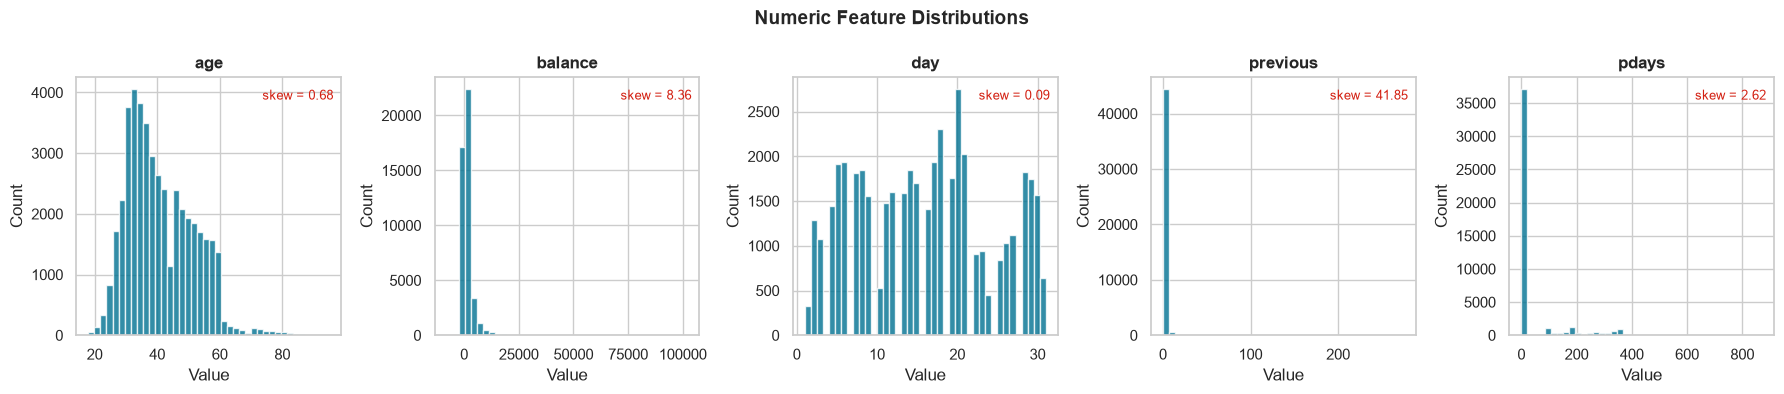

In [ ]:
num_cols = ['age', 'balance', 'day', 'previous', 'pdays']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))

for i, col in enumerate(num_cols):
    axes[i].hist(data[col], bins=40, color=PRIMARY, edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    skew_val = data[col].skew()
    axes[i].annotate(f'skew = {skew_val:.2f}', xy=(0.97, 0.95),xycoords='axes fraction', ha='right', va='top',fontsize=9, color=RATE_LINE)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Inference:
1. balance is heavily right-skewed (long tail toward high values). This is why the Logistic Regression pipeline requires PowerTransformer (Yeo-Johnson) since linear models are sensitive to this. Tree-based models are not, so RF and XGBoost don't need it.
2. pdays is dominated by -1 values (never contacted). Treating it as a raw numeric is misleading, which is why the feature engineer converts it into a binary contacted_before flag and replaces -1 with 0.
3. age, day are reasonably distributed with no extreme skew.
4. previous is heavily concentrated at 0 meaning that most customers were never contacted before.

## IV. EDA

### Fig 1: Dataset Imbalance

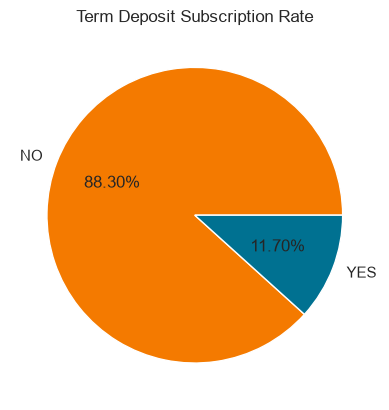

In [ ]:
# value_counts returns NO first (majority class), YES second
# Colors mapped to match the binary palette used throughout: NO=SECONDARY, YES=PRIMARY
data['y'].value_counts().plot(kind='pie',autopct='%.2f%%',colors=[SECONDARY, PRIMARY],ylabel='')
plt.title('Term Deposit Subscription Rate')
plt.show()

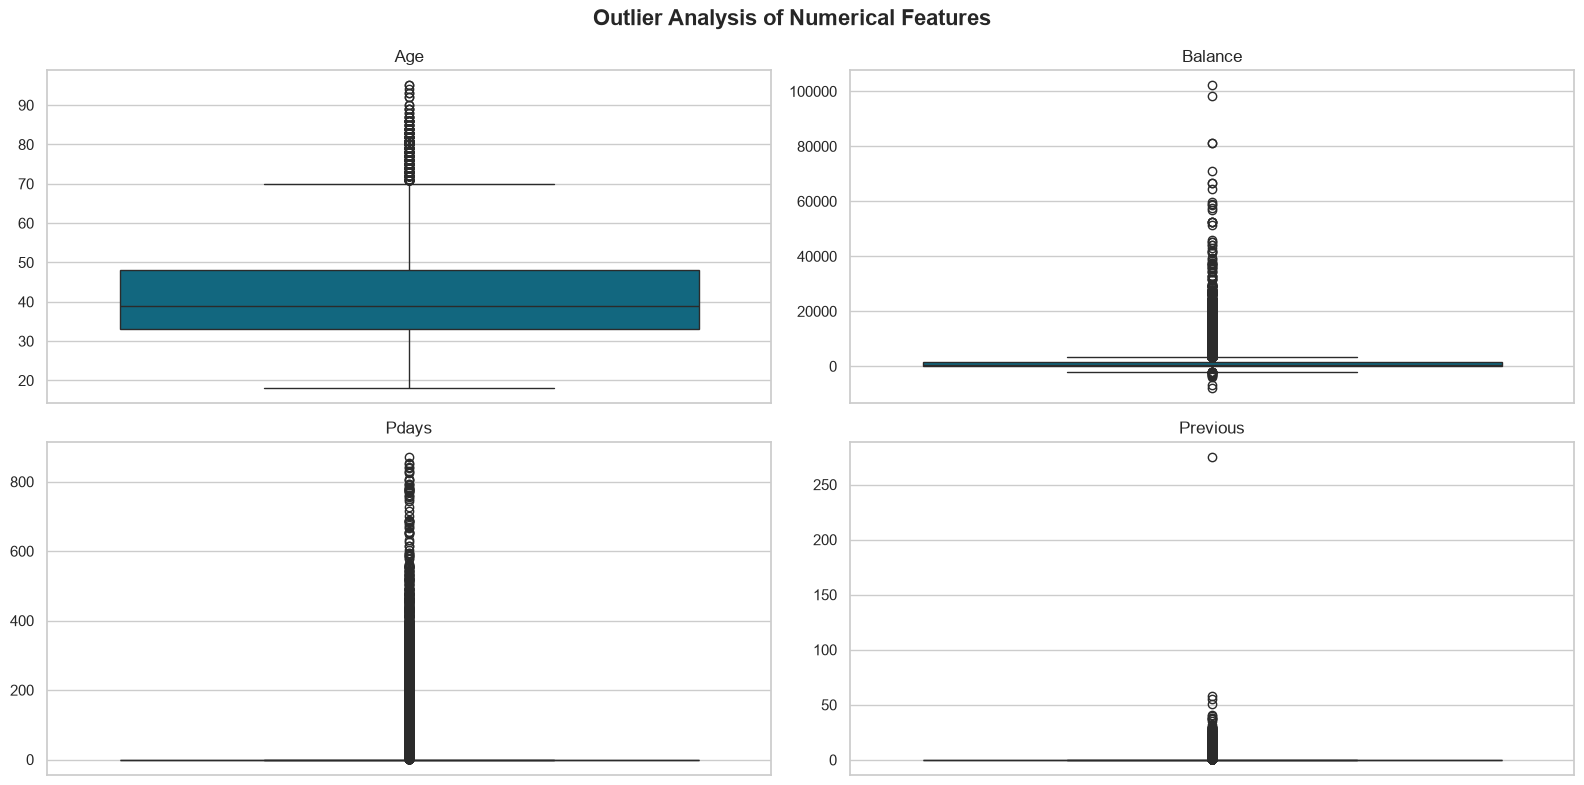

In [ ]:
num_cols = ['age','balance','pdays','previous']

fig, axes = plt.subplots(2,2, figsize=(16,8))
axes = axes.flatten()

for i,col in enumerate(num_cols):
    sns.boxplot(y=data[col],ax=axes[i],color=PRIMARY)
    axes[i].set_title(col.title())
    axes[i].set_ylabel('')

plt.suptitle('Outlier Analysis of Numerical Features',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

### Inference:
1) Only 11.70% of customers subscribed. The dataset is highly imbalanced. This means accuracy is a useless metric since even a model predicting NO every time scores 88%. Using ROC-AUC and F1 instead, and handling imbalance.
2) Age is well balanced. The outliers can be handled by binning easily. Balance has a huge number of outliers, but they can't be discluded since those are the highest paying customers, so we will bin again. previous and pdays outliers are valid since the volume of contacts is usually in the single digits to prevent wasting calls.


### Q1: Who Should We Target?

#### Fig 2: Demographic Segments (Volume vs Subscription Rate)


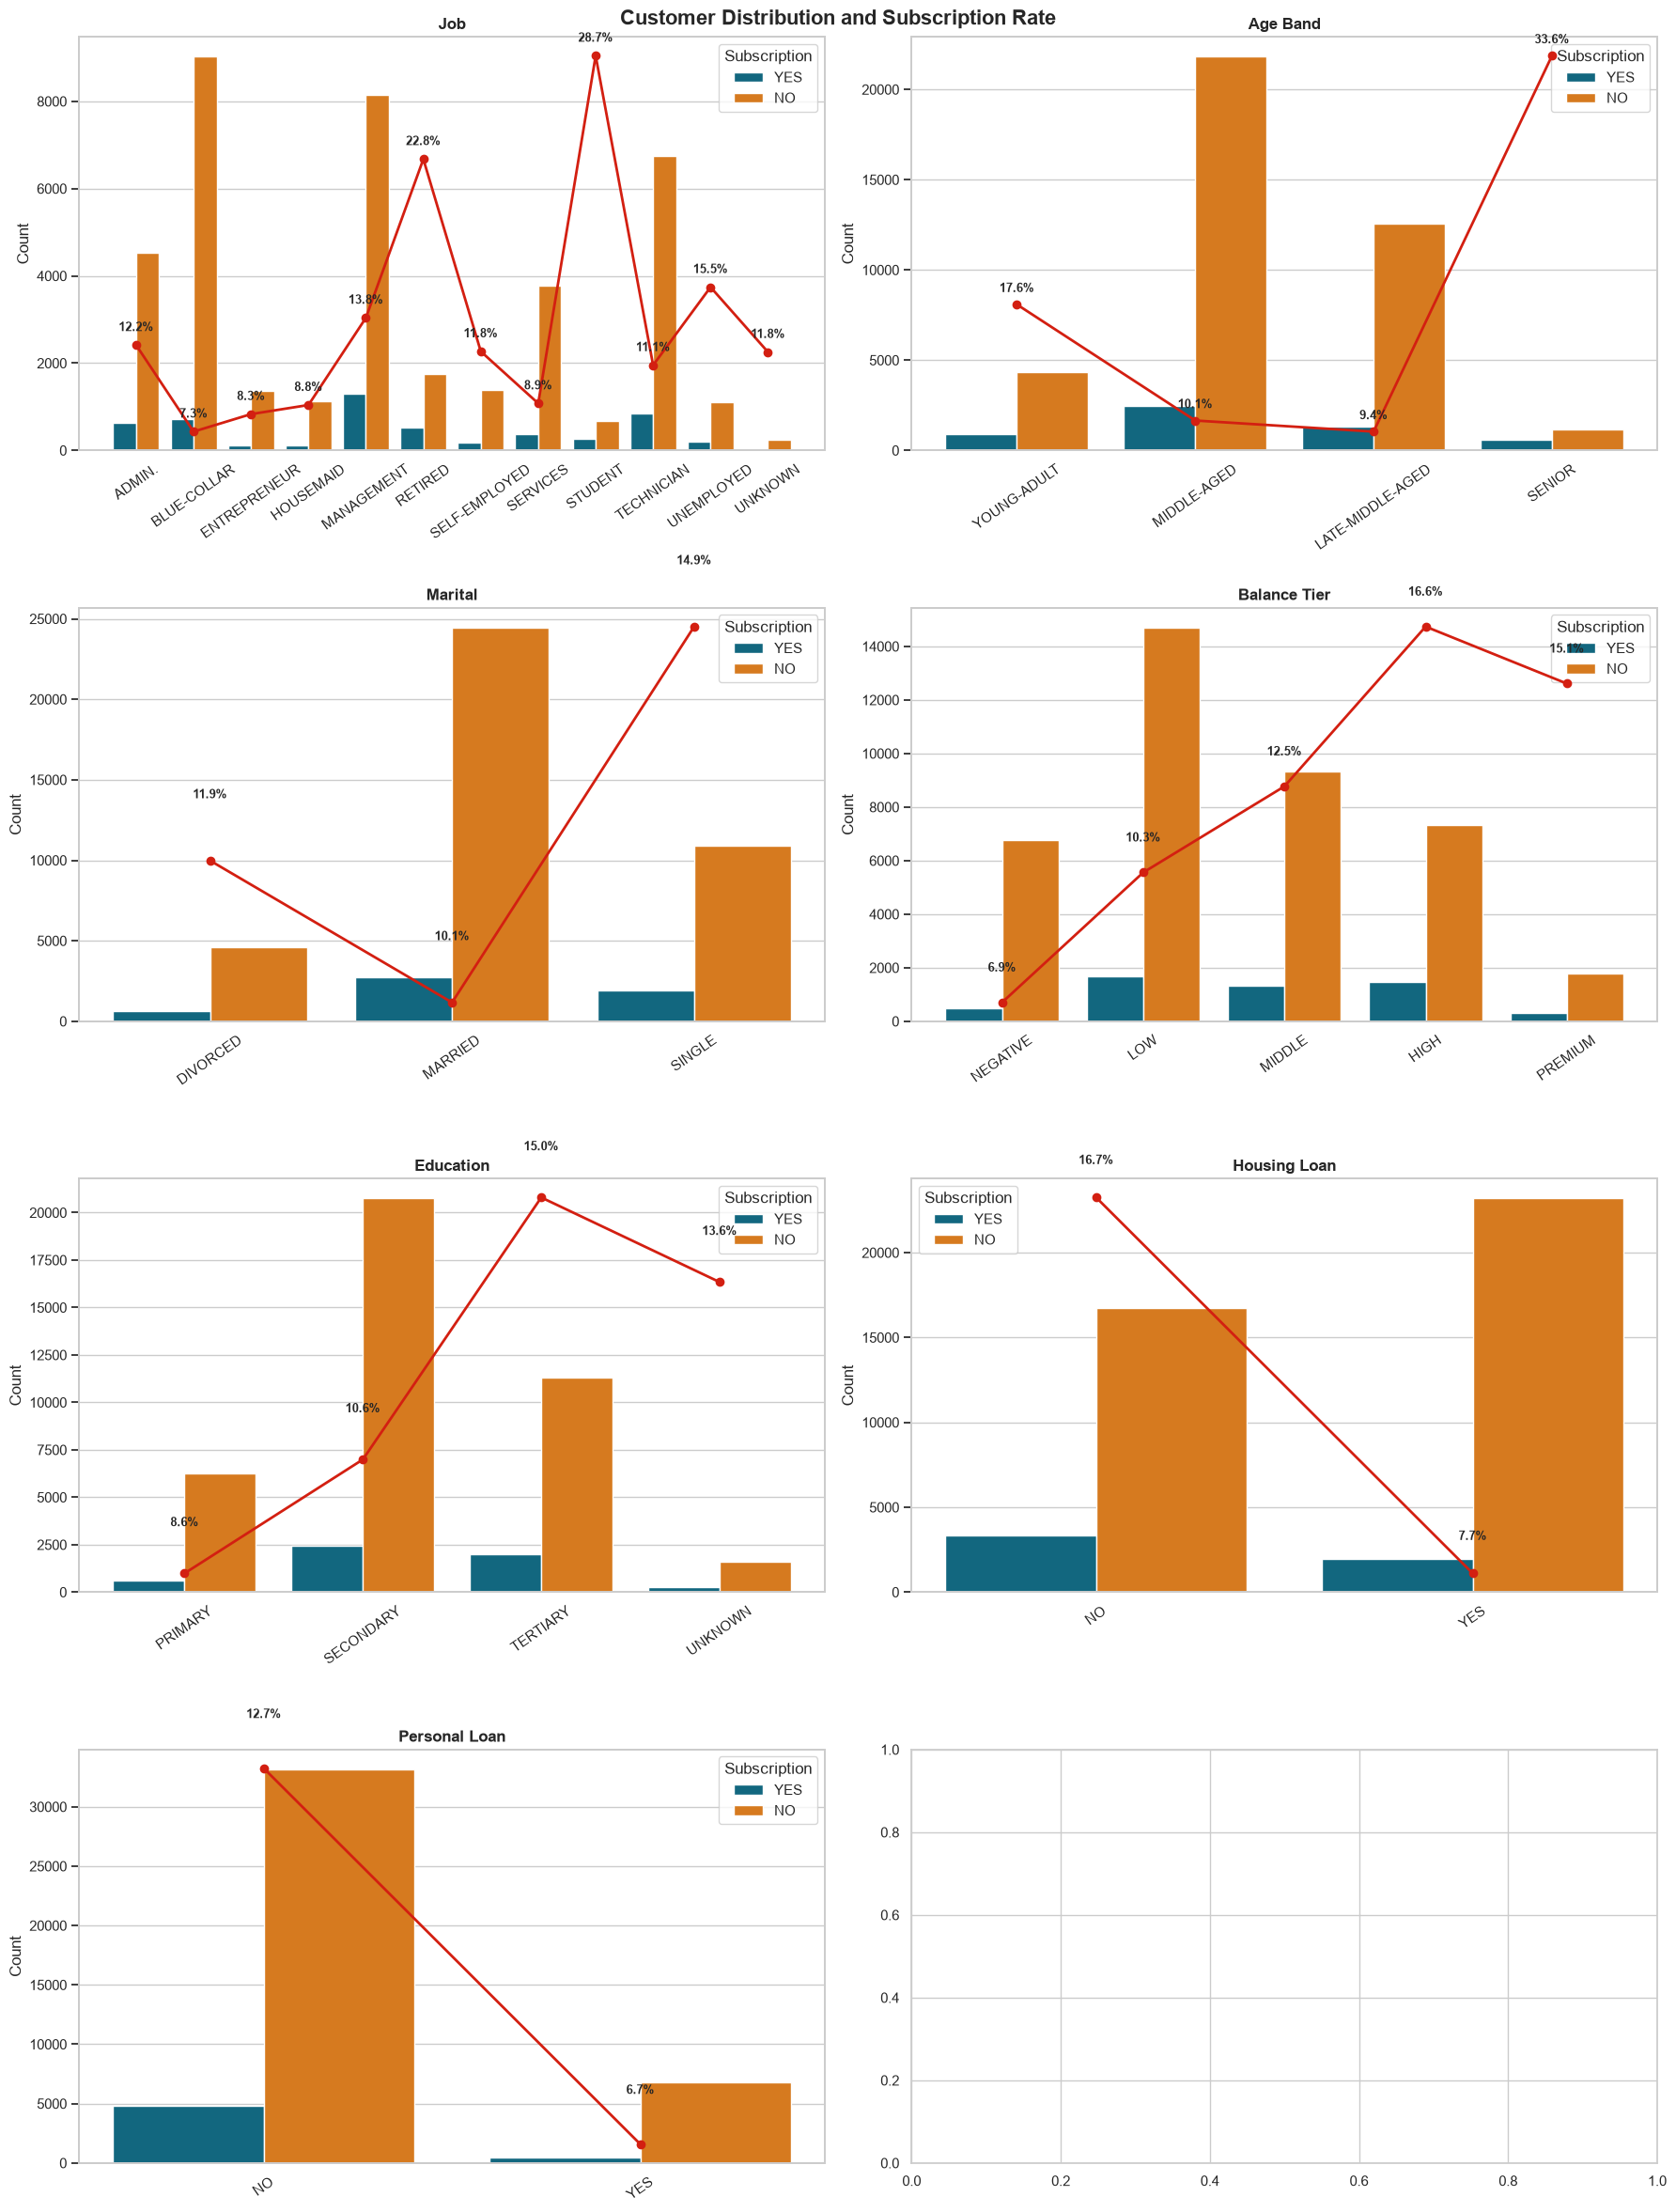

In [ ]:
segments = {'Job': 'job',
            'Age Band': 'age_band',
            'Marital': 'marital',
            'Balance Tier': 'tier',
            'Education': 'education',
            'Housing Loan': 'housing',
            'Personal Loan': 'loan'}

fixed_orders = {'age_band':['YOUNG-ADULT','MIDDLE-AGED','LATE-MIDDLE-AGED','SENIOR'],
                'tier':['NEGATIVE','LOW','MIDDLE','HIGH','PREMIUM']}

baseline = (data['y']=='YES').mean()*100
fig, axes = plt.subplots(4,2,figsize=(18,24))
axes = axes.flatten()

for i,(title,col) in enumerate(segments.items()):
    counts = pd.crosstab(data[col],data['y'])
    counts['Rate'] = counts['YES']/(counts['YES']+counts['NO'])*100
    counts = counts.reset_index()

    if col in fixed_orders:
        counts[col]=pd.Categorical(counts[col],categories=fixed_orders[col],ordered=True) 
        counts=counts.sort_values(col)

    counts_long = counts.melt(id_vars=[col,'Rate'],value_vars=['YES','NO'],var_name='Subscription',value_name='Count')

    ax1=axes[i]
    ax2=ax1.twinx()

    sns.barplot(data=counts_long,x=col,y='Count',hue='Subscription',palette=BINARY_PALETTE,ax=ax1)

    ax2.plot(range(len(counts)),counts['Rate'],color=RATE_LINE,marker='o',linewidth=2)
    for x,y in enumerate(counts['Rate']):
        ax2.text(x,y+0.8,f'{y:.1f}%',ha='center',fontsize=9,fontweight='bold')

    ax1.set_title(title,fontweight='bold')
    ax1.set_xlabel('')
    ax1.tick_params(axis='x',rotation=35)
    ax2.get_yaxis().set_visible(False)

plt.suptitle('Customer Distribution and Subscription Rate',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

### Inferences:

1) Age Band:
1. Middle-aged customers are the largest group but have below-baseline conversion. Likely due to mortgages, children, and financial commitments.
2. Seniors convert well despite smaller numbers. Possibly because retirement savings and preference for low-risk fixed-income products.
3. Young adults also show above-baseline rates. Possibly because of fewer financial commitments.

2) Job:
1. Students (~28%) and Retired (~22%) have the highest subscription rates despite low volume.
2. Blue-collar workers are the largest group but convert at only ~7%. This is the biggest source of wasted calls.
3. Management and admin have decent rates and reasonable volume. It's a good balance of rate and scale.

3) Balance Tier: Subscription rates are relatively consistent across tiers. Balance alone is not a strong targeting signal.

4) Marital: Single customers convert slightly better than married. Likely due to fewer joint financial commitments.

5) Education:
1. Tertiary-educated customers convert slightly better than primary-educated ones, likely due to higher income and greater awareness of financial products.
2. The effect is mild so education is a weak signal on its own but reinforces the job finding.

6) Housing Loan:
1. Customers without a housing loan convert at a higher rate than those with one.
2. A housing loan is a large ongoing commitment that reduces disposable income available for a term deposit so it makes sense.

7) Personal Loan:
1. Customers without a personal loan convert better.
2. Combined with housing loan, customers carrying both types of debt are the least likely to subscribe. Use loan burden as a soft negative signal in targeting.

### Q2: When Should Campaigns Run?
#### Fig 3: Campaign Volume vs Conversion Rate by Month

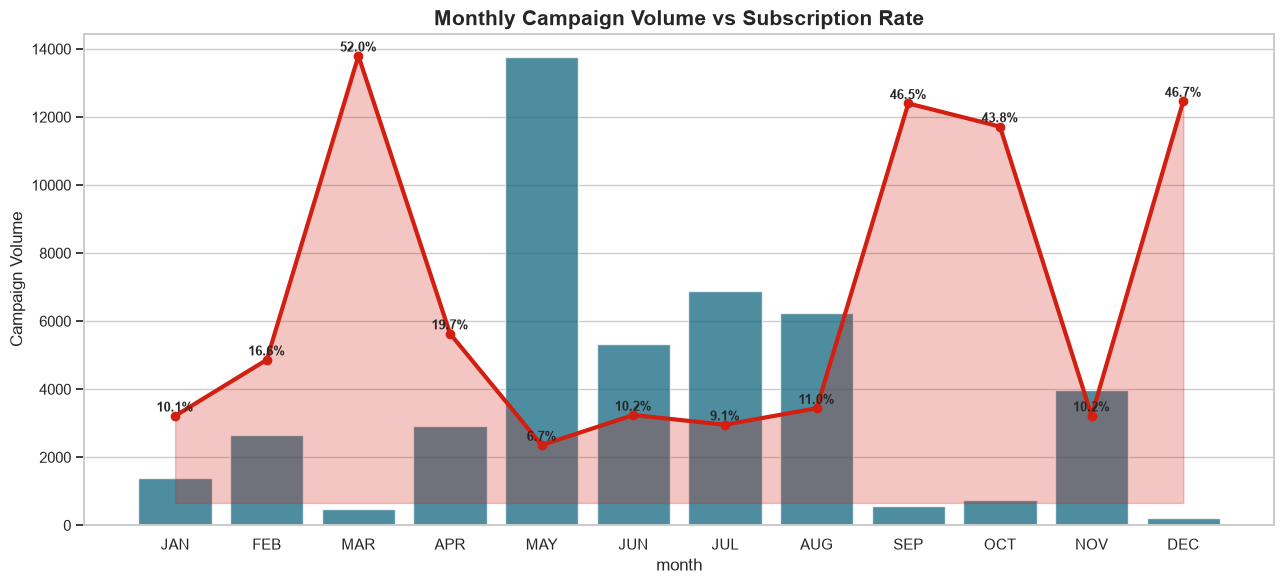

In [ ]:
month_order = ['JAN','FEB','MAR','APR','MAY','JUN',
               'JUL','AUG','SEP','OCT','NOV','DEC']

monthly = pd.crosstab(data['month'],data['y'])
monthly['Total']=monthly['YES']+monthly['NO']
monthly['Rate']=monthly['YES']/monthly['Total']*100
monthly=monthly.reset_index()
monthly['month']=pd.Categorical(monthly['month'],categories=month_order,ordered=True)
monthly=monthly.sort_values('month')

fig,ax1=plt.subplots(figsize=(13,6))

ax2=ax1.twinx()

sns.barplot(data=monthly,x='month',y='Total',alpha=.75,ax=ax1)

ax2.plot(monthly['month'],monthly['Rate'],color=RATE_LINE,marker='o',linewidth=3)
ax2.fill_between(monthly['month'].astype(str),monthly['Rate'],alpha=.25,color=RATE_LINE)

for x,y in enumerate(monthly['Rate']):
    ax2.text(x,y+0.5,f'{y:.1f}%',ha='center',fontsize=9,fontweight='bold')

ax1.set_ylabel('Campaign Volume')
ax2.get_yaxis().set_visible(False)

plt.title('Monthly Campaign Volume vs Subscription Rate',fontsize=15,fontweight='bold')

plt.tight_layout()
plt.show()

### Inference:
1. March has the lowest call volume but the highest conversion rate (quality over quantity).
2. May has the highest call volume but one of the lowest rates whiwch indicates that thebudget is being over-spent here.
3. September, October, December also show strong conversion rates.
4. Prioritise Q1 and Q4 for campaigns. Don't dump budget into May just because it's historically the busiest month.


### Q3: Which Contact Channel Is Most Effective?
### Fig 4: Subscription Rate by Contact Type

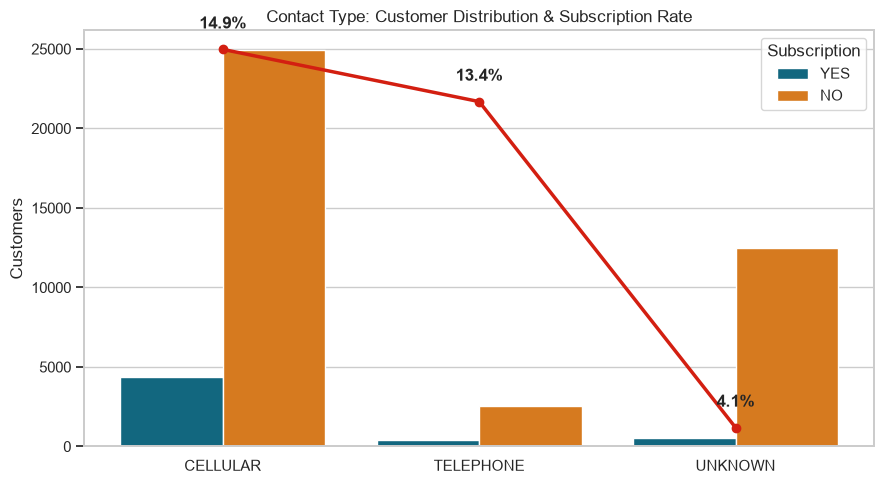

In [ ]:
contact_stats = pd.crosstab(data['contact'], data['y'])

contact_stats['Rate'] = (contact_stats['YES'] /(contact_stats['YES'] + contact_stats['NO']) * 100)

contact_stats = (contact_stats.sort_values('Rate', ascending=False).reset_index())
contact_long = contact_stats.melt(id_vars=['contact', 'Rate'],value_vars=['YES', 'NO'],var_name='Subscription',value_name='Count')
baseline = (data['y'] == 'YES').mean() * 100

fig, ax1 = plt.subplots(figsize=(9,5))
ax2 = ax1.twinx()

sns.barplot(data=contact_long,x='contact',y='Count',hue='Subscription',palette=BINARY_PALETTE,ax=ax1)

ax2.plot(range(len(contact_stats)),contact_stats['Rate'],marker='o',linewidth=2.5,color=RATE_LINE)

for x, y in enumerate(contact_stats['Rate']):
    ax2.text(x,y + 0.6,f'{y:.1f}%',ha='center',fontweight='bold')

ax1.set_ylabel('Customers')
ax2.get_yaxis().set_visible(False)
ax1.set_xlabel('')
plt.title('Contact Type: Customer Distribution & Subscription Rate')
plt.tight_layout()
plt.show()

### Inference:
1. Cellular achieves the highest conversion rate (~15%) and should be the primary contact channel.
2. Unknown contact (~7%) likely represents customers reached through non-phone channels (mail, walk-in). These people showed some initiative, making them warmer leads than telephone cold-calls.
3. Telephone performs worst (~5%) should be used sparingly.


### Q4: How Many Times Should We Contact a Customer Before It Becomes Ineffective?
#### Fig 5: Subscription Rate vs Number of Previous Campaign Contacts


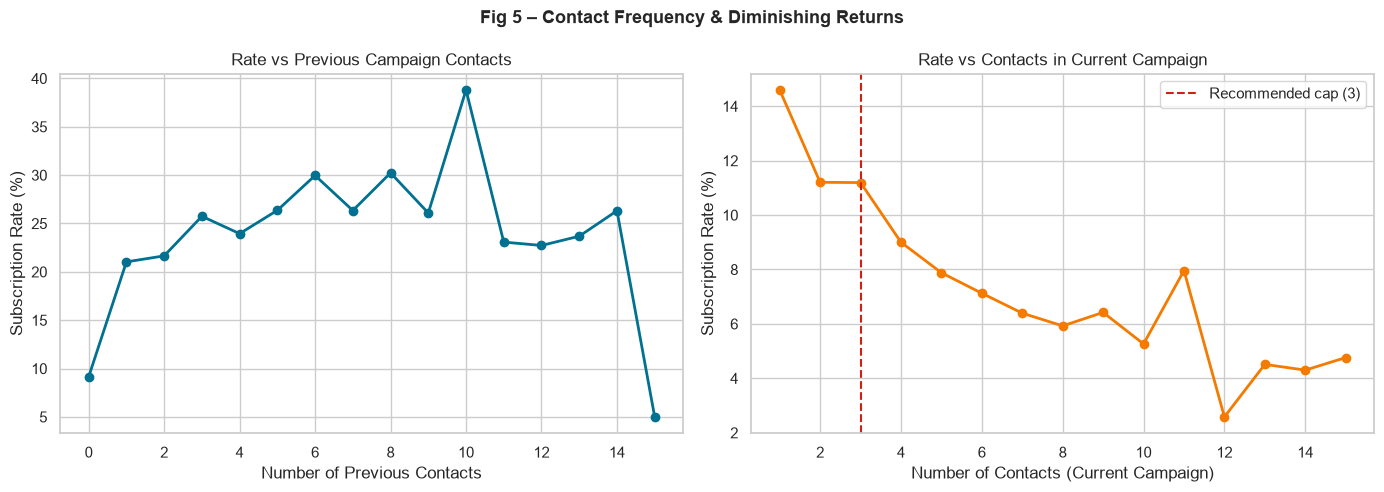

In [ ]:
#we use 'previous' (contacts BEFORE this campaign) not 'campaign'
#'campaign' is dropped because it won't exist at prediction time.
#But we can still draw the business inference from it in EDA.

prev_stats = (
    data.groupby('previous')['y']
    .apply(lambda x: (x == 'YES').mean() * 100)
    .reset_index(name='rate'))
prev_capped = prev_stats[prev_stats['previous'] <= 15]

camp_stats = (
    data.groupby('campaign')['y']
    .apply(lambda x: (x == 'YES').mean() * 100)
    .reset_index(name='rate'))
camp_capped = camp_stats[camp_stats['campaign'] <= 15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(prev_capped['previous'], prev_capped['rate'], marker='o', color=PRIMARY, linewidth=2)
axes[0].set_title('Rate vs Previous Campaign Contacts')
axes[0].set_xlabel('Number of Previous Contacts')
axes[0].set_ylabel('Subscription Rate (%)')

axes[1].plot(camp_capped['campaign'], camp_capped['rate'], marker='o', color=SECONDARY, linewidth=2)
axes[1].axvline(x=3, color=RATE_LINE, linestyle='--', linewidth=1.5, label='Recommended cap (3)')
axes[1].set_title('Rate vs Contacts in Current Campaign')
axes[1].set_xlabel('Number of Contacts (Current Campaign)')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].legend()

plt.suptitle('Fig 5 – Contact Frequency & Diminishing Returns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Inference:
1. Conversion rate drops sharply after 3 contacts in the current campaign.
2. Customers contacted more than 5 times show near-zero conversion , continuing to call them wastes money and damages goodwill.
3.  Cap contact attempts at 3 per campaign. Flag anyone contacted 4+ times for suppression.


### Q5: Does the Previous Campaign Outcome Predict Future Success?
#### Fig 6: Subscription Rate by Previous Campaign Outcome

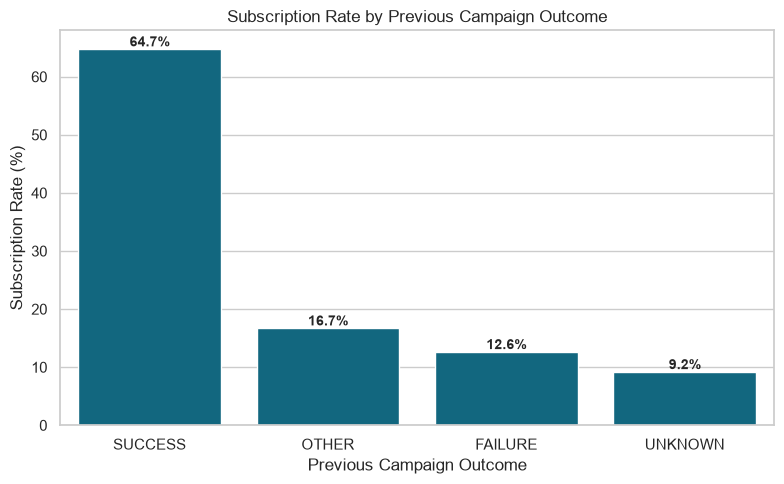

In [ ]:
pout_stats = (
    data.groupby('poutcome')['y']
    .agg(customers='count', subscriptions=lambda x: (x == 'YES').sum())
    .assign(subscription_rate=lambda d: d['subscriptions'] / d['customers'] * 100)
    .sort_values('subscription_rate', ascending=False)
    .reset_index())

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=pout_stats, x='poutcome', y='subscription_rate', color=PRIMARY, ax=ax)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',(p.get_x() + p.get_width() / 2, p.get_height()),ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate (%)')
plt.tight_layout()
plt.show()


### Inference:
1. Customers with a previous SUCCESS convert at ~65% which makes it by far the strongest signal in the dataset.
2. Before anything else, pull every customer who said YES in a previous campaign and call them first.
3. UNKNOWN poutcome (~10%) still outperforms FAILURE since these are first-time contacts with no prior baggage.


## V. Modelling

#### 5.1 Define X and y

In [ ]:
# Drop EDA helper columns and leakage columns
# duration: only known after the call ends, so it cannot be used at prediction time (target leakage)
# campaign: refers to the current campaign's call count, which does not exist before the campaign runs
# previously_contacted: already encoded as a proper binary feature (contacted_before) inside FeatEngineer
DROP = ['duration', 'campaign','previously_contacted']

datam = data.drop(columns=DROP)

y = datam['y'].map({'NO': 0, 'YES': 1})
X = datam.drop(columns=['y'])

print(f"X shape: {X.shape}")
print(f"Positive rate (y=1): {y.mean():.3f}")
print(f"\nColumns in X:\n{list(X.columns)}")

X shape: (45211, 16)
Positive rate (y=1): 0.117

Columns in X:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'pdays', 'previous', 'poutcome', 'age_band', 'tier']


### 5.2 Train-Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42,stratify=y)

print(f"Train: {len(X_train):,} samples\nPositive rate: {y_train.mean():.3f}")
print(f"Test:  {len(X_test):,} samples\nPositive rate: {y_test.mean():.3f}")


Train: 36,168 samples
Positive rate: 0.117
Test:  9,043 samples
Positive rate: 0.117


### 5.3 Feature Engineering

1) contacted_before: binary flag (was pdays != -1?)
2) month_num: integer 1–12
3) month_sin / month_cos: cyclic encoding so December and January are treated as close together
4) Drops original month and pdays columns


In [ ]:
class FeatEngineer(BaseEstimator, TransformerMixin):
    MONTH_MAP = {'JAN':1,
                 'FEB':2,
                 'MAR':3,
                 'APR':4,
                 'MAY':5,
                 'JUN':6,
                 'JUL':7,
                 'AUG':8,
                 'SEP':9,
                 'OCT':10,
                 'NOV':11,
                 'DEC':12}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        #-1 means never contacted before, so created a binary feature and replaced -1 with 0 for modeling
        df['contacted_before'] = (df['pdays'] != -1).astype(int)
        df['pdays']= df['pdays'].replace(-1, 0)

        #cyclic month encoding to keep the total number of features low
        df['month_num'] = df['month'].map(self.MONTH_MAP)
        df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
        df = df.drop(columns=['month'])

        return df

#sanity check

sample = FeatEngineer().fit_transform(X_train.head(3))
print("After feature engineering:")
print(list(sample.columns))
print("No. of columns:", len(sample.columns))


After feature engineering:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'pdays', 'previous', 'poutcome', 'age_band', 'tier', 'contacted_before', 'month_num', 'month_sin', 'month_cos']
No. of columns: 19


### 5.4 Preprocessing Pipelines
1) Tree preprocessor for Random Forest and XGBoost: Only OneHotEncoding for categorical columns.  
2) Logistic Regression preprocessor: RobustScaler for numerics, PowerTransformer for balance (heavily skewed), OneHotEncoding for categories.


In [ ]:
# Numeric features passed through preprocessing
# month_num, month_sin, month_cos are produced inside FeatEngineer from the raw month column
# contacted_before and pdays (with -1 replaced) are also FeatEngineer outputs
NUM_FEAT = ['day', 'previous','month_num', 'month_sin', 'month_cos', 'pdays', 'contacted_before']

# age_band and tier are the binned features
CAT_FEAT = ['age_band', 'tier', 'job', 'marital', 'education', 'default','housing', 'loan', 'contact', 'poutcome']

# Tree preprocessor: tree-based models are insensitive to feature scaling,so only OneHotEncoding is needed
tree_prep = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEAT)], remainder='passthrough')

# balance is separated because of extreme right skew and requires a separate PowerTransformer step (Yeo-Johnson handles negative values)
NUM_FEAT_NO_BAL = [f for f in NUM_FEAT if f != 'balance']

# Logistic Regression preprocessor
# RobustScaler is used for numerics because it is resistant to the outliers seen in pdays/previous
# PowerTransformer normalises the balance distribution before scaling
lr_prep = ColumnTransformer(transformers=[('num', RobustScaler(),NUM_FEAT_NO_BAL),
                                          ('bal', PowerTransformer(method='yeo-johnson'),['balance']),
                                          ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEAT)])

### 5.5 Model Pipelines & Cross-Validation


In [ ]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

pipelines = {
    # Baseline model
    'Logistic Regression': Pipeline([('fe',FeatEngineer()),
                                     ('prep', lr_prep),
                                     ('model',LogisticRegression(class_weight='balanced', max_iter=100, random_state=42))]),

    'Random Forest': Pipeline([('fe',FeatEngineer()),
                               ('prep',tree_prep),
                               ('model',RandomForestClassifier(class_weight='balanced', n_estimators=100,max_depth=5, random_state=42, n_jobs=-1))]),

    'XGBoost': Pipeline([('fe',FeatEngineer()),
                         ('prep',tree_prep),
                         ('model', XGBClassifier(scale_pos_weight=scale_pos,n_estimators=50, max_depth=5, learning_rate=0.05,subsample=0.8, colsample_bytree=0.8,eval_metric='logloss', random_state=42, n_jobs=-1))])
}

In [ ]:
# StratifiedKFold preserves the 88/12 class ratio in every fold
cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ROC-AUC measures ranking quality: how well the model separates subscribers from non-subscribers
# F1 balances precision (call quality) and recall (subscriber coverage)
# Precision and recall are reported separately to show the precision-recall tradeoff per model
scoring= ['roc_auc', 'f1', 'precision', 'recall']
cv_results= {}

for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {m: scores[f'test_{m}'].mean() for m in scoring}

cv_df = pd.DataFrame(cv_results).T.sort_values('roc_auc', ascending=False)
print("\nCross-Validation Results:")
print(cv_df.round(4))


Cross-Validation Results:
                     roc_auc      f1  precision  recall
XGBoost               0.7865  0.4322     0.3365  0.6053
Random Forest         0.7697  0.4101     0.3129  0.5982
Logistic Regression   0.7503  0.3517     0.2429  0.6374


### Inference:
1. Precision: Of the customers predicted to subscribe, the percentage that actually subscribed.
2. Recall: Of all customers who actually subscribed, the percentage correctly identified by the model.
3. Logistic Regression achieved the highest recall, meaning it identified the largest proportion of potential subscribers. However, its low precision indicates that it also generated many false positives.
4. Random Forest and XGBoost achieved substantially higher precision while maintaining competitive recall, resulting in much stronger F1-scores.
5. XGBoost produced the highest ROC-AUC (0.796), demonstrating the strongest overall ability to distinguish between subscribers and non-subscribers across all classification thresholds.
6. Considering ROC-AUC, F1-score, and the balance between precision and recall, XGBoost was selected as the final model.

### 5.6 Final Evaluation on the Test Set

In [ ]:
chosen_one= cv_df.index[0]
best_pipe= pipelines[chosen_one]

print(f"Best model from CV: {chosen_one}")

best_pipe.fit(X_train, y_train)

y_pred= best_pipe.predict(X_test)
y_pred_proba= best_pipe.predict_proba(X_test)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Test F1:{f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No Subscribe', 'Subscribe']))


Best model from CV: XGBoost

Test ROC-AUC: 0.8033
Test F1:0.4543

              precision    recall  f1-score   support

No Subscribe       0.95      0.85      0.89      7985
   Subscribe       0.35      0.64      0.45      1058

    accuracy                           0.82      9043
   macro avg       0.65      0.74      0.67      9043
weighted avg       0.88      0.82      0.84      9043



### 5.7 Confusion Matrix and ROC Curve

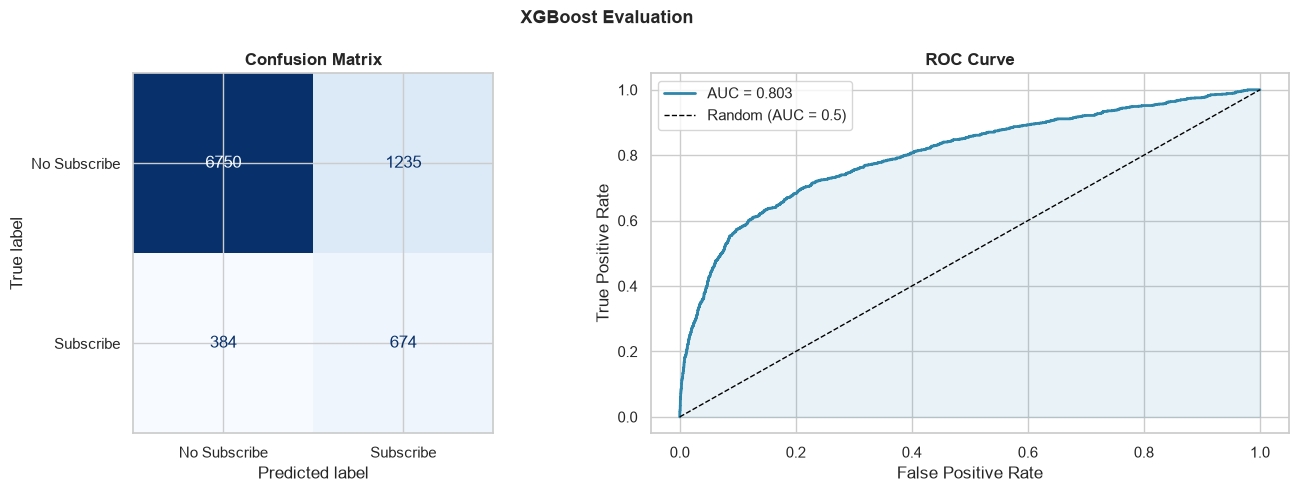

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Subscribe', 'Subscribe']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score   = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, lw=2, color=PRIMARY, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color=PRIMARY)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle(f'{chosen_one} Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Inference:
1. The model correctly suppresses a large share of non-subscribers, keeping campaign costs low.
2. False Negatives (bottom-left of the matrix) are real subscribers the model missed. These are the costly errors since each one is a lost revenue opportunity.
3. False Positives (top-right) are wasted calls, but they are far less expensive than missed conversions.
4. The ROC-AUC well above 0.5 confirms the model has genuine discriminative power and is not simply exploiting the class imbalance.
5. The decision threshold can be lowered below 0.5 to recover more subscribers at the cost of more wasted calls, which is appropriate when campaign capacity is high.

### 5.8 Feature importance

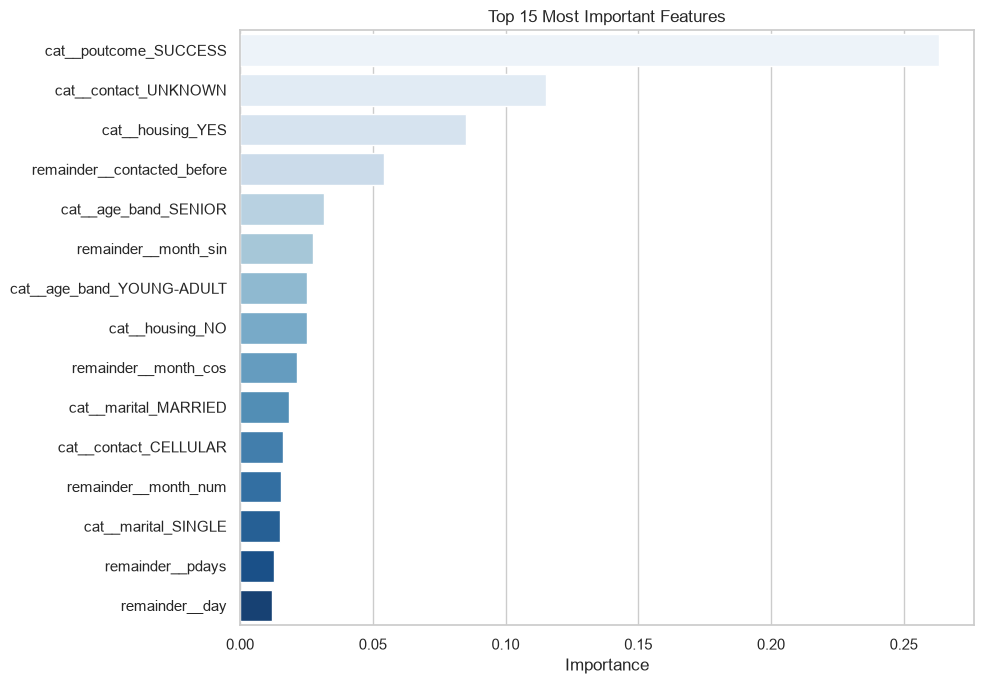

In [ ]:

feature_names = best_pipe.named_steps['prep'].get_feature_names_out()

importance = pd.Series(best_pipe.named_steps['model'].feature_importances_,index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(x=importance.values[:15], y=importance.index[:15], palette=SEQ_CMAP)
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Inference:
1. poutcome_SUCCESS is by far the strongest predictor, confirming the EDA finding that prior campaign success drives future conversion.
2. contact_UNKNOWN ranks second, thsi is likely because these customers contacted the bank via methods other than cellular and telephone, whether in person or such, showing proactivity.
3. housing_YES / housing_NO and contacted_before round out the top tier, showing existing debt obligations and prior contact history meaningfully shape subscription likelihood.
4. Mid-range age bands, raw pdays, and day carry the least weight, suggesting the model relies more on engineered and tail-end demographic features than granular timing details.

### 5.8 Propensity Scores and Targeting

The model outputs a propensity score (probability) for every customer.  
The default threshold is 0.5 but it can be adjusted based on the campaign budget:
1) Lower threshold: Call more people, catch more subscribers, but more wasted calls.
2) Higher threshold: Call fewer people, higher hit rate, but miss some subscribers.


In [ ]:
# Score every customer in the full dataset (train + test) to produce a campaign list
# predict_proba returns [P(NO), P(YES)]; index [:,1] extracts the subscriber probability
all_scores = best_pipe.predict_proba(X)[:, 1]

scored = X.copy()
scored['propensity_score']= all_scores
scored['actual_y']= y.values

# based on the propensity scores, we split into quantiles to create priority segments for the campaign list

bin_edges = [scored['propensity_score'].min() - 1e-6,
             scored['propensity_score'].quantile(0.25),
             scored['propensity_score'].quantile(0.60),
             scored['propensity_score'].quantile(0.90),
             scored['propensity_score'].max()]

scored['priority'] = pd.cut(
    scored['propensity_score'],
    bins=bin_edges,
    labels=['DO NOT CONTACT', 'LOW PRIORITY', 'MEDIUM PRIORITY', 'HIGH PRIORITY'],
    include_lowest=True
)

summary = (scored.groupby('priority', observed=True)
    .agg(customer_count=('propensity_score', 'count'),avg_score=('propensity_score', 'mean'),actual_sub_rate=('actual_y', 'mean'))
    .assign(pct_of_base=lambda d: d['customer_count'] / d['customer_count'].sum() * 100)
    .reset_index())

print(summary.round(3).to_string(index=False))


       priority  customer_count  avg_score  actual_sub_rate  pct_of_base
 DO NOT CONTACT           11303      0.149            0.013       25.001
   LOW PRIORITY           15824      0.281            0.039       35.000
MEDIUM PRIORITY           13563      0.485            0.142       29.999
  HIGH PRIORITY            4521      0.855            0.576       10.000


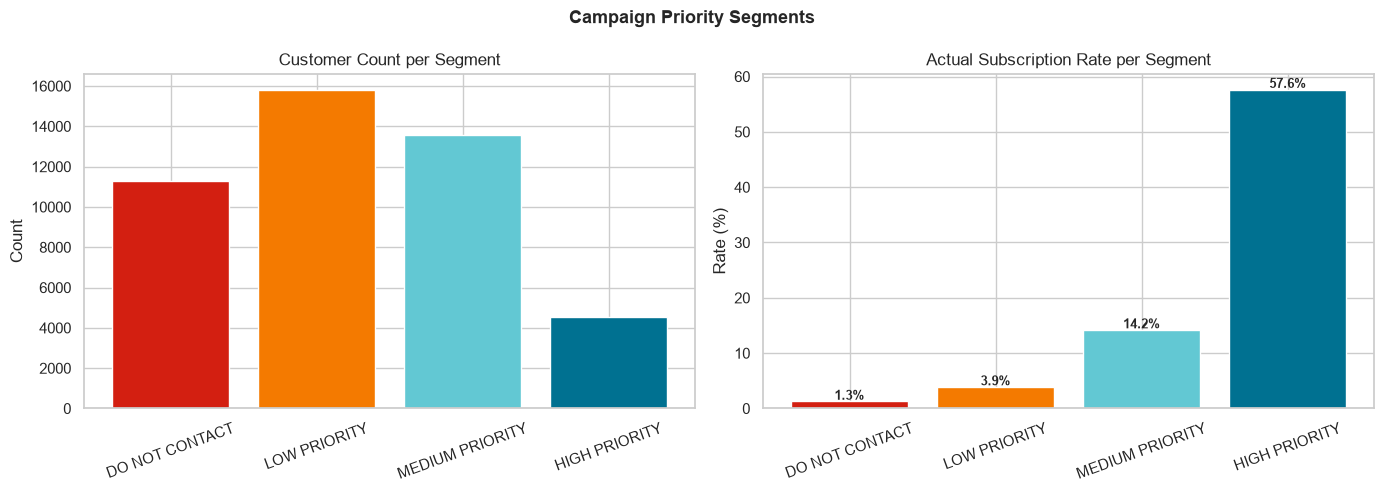

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_colors = SEG_COLORS
colors = [seg_colors[s] for s in summary['priority']]

axes[0].bar(summary['priority'], summary['customer_count'], color=colors, edgecolor='white')
axes[0].set_title('Customer Count per Segment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(summary['priority'], summary['actual_sub_rate'] * 100, color=colors, edgecolor='white')
axes[1].set_title('Actual Subscription Rate per Segment')
axes[1].set_ylabel('Rate (%)')
axes[1].tick_params(axis='x', rotation=20)

for bar, val in zip(axes[1].patches, summary['actual_sub_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,f'{val*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Campaign Priority Segments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Inference:

Campaign Recommendation:  
HIGH PRIORITY: Call immediately via Cellular, max 3 attempts  
MEDIUM PRIORITY: Call via Cellular, max 2 attempts  
LOW PRIORITY: Digital/mail only, no outbound calls  
DO NOT CONTACT: Suppress from campaign entirely  

### 5.9 Customer Segment Ranking

Cross-reference propensity scores with EDA-derived demographic features to build customer profiles to target

In [ ]:
scored_profile = scored.copy()
cols = ['age_band', 'tier', 'job', 'education', 'housing', 'loan', 'poutcome', 'contact', 'previously_contacted']
scored_profile[cols] = data[cols].values

overall_pct = {}
profile_cols = ['job', 'age_band', 'education', 'contact', 
                'poutcome', 'housing', 'loan', 'previously_contacted']

for col in profile_cols:
    overall_pct[col] = (
        scored_profile[col]
        .value_counts(normalize=True)
        .mul(100)
    )
    
#Top characteristics by LIFT over baseline
print("CUSTOMER SEGMENT PROFILES")

for tier in ['HIGH PRIORITY', 'MEDIUM PRIORITY', 'LOW PRIORITY', 'DO NOT CONTACT']:
    grp = scored_profile[scored_profile['priority'] == tier]
    n   = len(grp)
    avg_score = grp['propensity_score'].mean()
    sub_rate  = grp['actual_y'].mean() * 100

    print(f"\n{'─'*70}")
    print(f"  {tier}  ({n:,} customers | avg score: {avg_score:.2f} | sub rate: {sub_rate:.1f}%)")
    print(f"{'─'*70}")

    for col in profile_cols:
        tier_pct = grp[col].value_counts(normalize=True).mul(100)

        # lift = tier % / overall %
        lift = (tier_pct / overall_pct[col]).dropna().sort_values(ascending=False)

        top_val  = lift.index[0]
        top_lift = lift.iloc[0]
        top_pct  = tier_pct.get(top_val, 0)
        base_pct = overall_pct[col].get(top_val, 0)

        print(f"  {col}: {top_val}  "
              f"({top_pct:.1f}% in tier vs {base_pct:.1f}% overall)")

CUSTOMER SEGMENT PROFILES

──────────────────────────────────────────────────────────────────────
  HIGH PRIORITY  (4,521 customers | avg score: 0.85 | sub rate: 57.6%)
──────────────────────────────────────────────────────────────────────
  job: STUDENT  (8.3% in tier vs 2.1% overall)
  age_band: SENIOR  (19.5% in tier vs 3.9% overall)
  education: TERTIARY  (43.4% in tier vs 29.4% overall)
  contact: CELLULAR  (90.2% in tier vs 64.8% overall)
  poutcome: SUCCESS  (30.3% in tier vs 3.3% overall)
  housing: NO  (81.6% in tier vs 44.4% overall)
  loan: NO  (96.4% in tier vs 84.0% overall)
  previously_contacted: YES  (51.4% in tier vs 18.3% overall)

──────────────────────────────────────────────────────────────────────
  MEDIUM PRIORITY  (13,563 customers | avg score: 0.48 | sub rate: 14.2%)
──────────────────────────────────────────────────────────────────────
  job: STUDENT  (2.5% in tier vs 2.1% overall)
  age_band: YOUNG-ADULT  (16.0% in tier vs 11.7% overall)
  education: TERTIARY

In [ ]:
#job x age_band subscription rate within each priority tier
archetype = (
    scored_profile[scored_profile['priority'].isin(['HIGH PRIORITY', 'MEDIUM PRIORITY'])]
    .groupby(['priority', 'job', 'age_band'], observed=True)['actual_y']
    .agg(count='count', sub_rate=lambda x: x.mean() * 100)
    .reset_index()
    .sort_values(['priority', 'sub_rate'], ascending=[True, False])
)

print("Top 5 Job x Age Band -> sub_rate combinations within HIGH and MEDIUM PRIORITY:\n")
for tier in ['HIGH PRIORITY', 'MEDIUM PRIORITY']:
    print(f"  {tier}")
    top5 = archetype[archetype['priority'] == tier].head(5)
    for _, row in top5.iterrows():
        print(f"{row['job'].title()} x {row['age_band'].title()} -> "
              f"sub_rate = {row['sub_rate']:.1f}%")
    print()


Top 5 Job x Age Band -> sub_rate combinations within HIGH and MEDIUM PRIORITY:

  HIGH PRIORITY
Housemaid x Young-Adult -> sub_rate = 100.0%
Student x Late-Middle-Aged -> sub_rate = 100.0%
Entrepreneur x Senior -> sub_rate = 85.7%
Unknown x Middle-Aged -> sub_rate = 85.7%
Blue-Collar x Senior -> sub_rate = 81.8%

  MEDIUM PRIORITY
Housemaid x Young-Adult -> sub_rate = 33.3%
Self-Employed x Senior -> sub_rate = 28.6%
Technician x Senior -> sub_rate = 26.5%
Unemployed x Senior -> sub_rate = 25.0%
Housemaid x Late-Middle-Aged -> sub_rate = 23.1%



### Inference:
1. The HIGH PRIORITY segment profile directly confirms the EDA findings that the model has independently learned the same patterns.
2. The Job x Age Band breakdown within HIGH PRIORITY shows the exact archetypes to build the campaign brief around.
3. LOW PRIORITY and DO NOT CONTACT segments reveal which combinations to suppress. This is as valuable as knowing who to call, because it protects budget.


## VI. Summary

| Question | Finding | Action |
|---|---|---|
| Who to target? | Students, Retired, Tertiary-educated, Single customers convert highest | Prioritise these segments first |
| Who NOT to target? | Blue-collar, Middle-aged, 4+ prior contacts, credit default | Suppress or digital-only |
| Best contact channel? | Cellular (~15% rate) dominates | Use cellular as primary channel |
| How often to contact? | Sharp drop-off after 3 calls | Hard cap at 3 per campaign |
| When to run campaigns? | March, September, October, December show highest rates | Prioritise Q1 and Q4 budgets |
| Previous campaign signal? | Prior SUCCESS → 65%+ conversion | Re-engage previous subscribers first |
| Previously contacted? | 3× higher rate than never-contacted | Build warm leads list from prior campaigns |
